In [21]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 2

In [169]:
m_list = list(range(5, 10)) + list(range(10, 301, 5))

print(m_list)

[5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300]


In [132]:
def center_data(mx):
    centered = np.array([row - np.mean(row) for row in mx])
    return centered

def pseudo_invers(SVD):
    sort_idx = np.argsort(SVD.S)[::-1]
    V = SVD.Vh.T[sort_idx, :]
    U = SVD.U[:,sort_idx]
    W = SVD.S[sort_idx]
    W_inv = np.array([1/w if w > 0.0000001 else 0 for w in W])
    return V @ np.diag(W_inv) @ U.T


In [168]:
np.linalg.eigvals(np.dot(cov_mx.T, cov_mx))

array([ 2.35214394e-01+0.00000000e+00j,  1.12564249e-01+0.00000000e+00j,
        1.00727926e-01+0.00000000e+00j,  1.21723483e-02+0.00000000e+00j,
        1.01802364e-03+0.00000000e+00j, -1.40873185e-17+0.00000000e+00j,
        7.48620818e-18+8.49268563e-19j,  7.48620818e-18-8.49268563e-19j,
       -3.58422748e-18+9.76483678e-19j, -3.58422748e-18-9.76483678e-19j])

In [ ]:

ranks = []
SVDs =[]
pseudo_invs = []
StoSp_prods = []
eucl_dist = []
for m in m_list:
    mx = np.abs(np.random.normal(0,1,(m*10))).reshape((10,m))
    mx_cent = center_data(mx)
    cov_mx = 1/(10 - 1) * np.dot(mx_cent.T, mx_cent)
    ranks.append(np.linalg.matrix_rank(cov_mx))
    SVDs.append(np.linalg.svd(cov_mx))
    ps_inv = pseudo_invers(SVDs[-1])
    my_inv = pseudo_invers(SVDs[-1])
    numpy_inv = np.linalg.pinv(cov_mx)

    # This should be a very small number, like 1e-15
    print(np.linalg.norm(my_inv - numpy_inv))
    #print(ps_inv)
    prod = cov_mx @ ps_inv
    eucl_dist.append(np.linalg.norm(prod - np.diag(np.ones(m))))

6.206335383118183e-16
4.48508116795402e-15
2.8109972208865576e-15
6.455746612997511e-15
4.124289582017995e-15
8.879930017745193e-15
2.34017990380566e-15
1.1298351348752731e-15
9.115469192669446e-16
6.824276109713542
4.008919481142169
3.7374590193315784
3.206093568944449
3.009236211400034
2.6680492738660786
2.1008010293106363
2.6130846767595624
1.900366016293571
1.4301161705013545
1.7892974180313441
1.6690150110870816
1.3050838699045209
1.2332866822704058
1.4361368648258708
1.1839953430165626
1.1199582162474362
0.9857619813548196
1.090025793020747
1.009458146194429
0.8057162155568925
0.7949791262192895
0.7715635848495598
0.6964754514362864
0.6264582551618854
0.6809288246127708
0.6567619524745422
0.6716042173456409
0.5844272314239063
0.5858272430493584
0.6299519336382247
0.601172233054673
0.5556467486222229
0.5408043073827454
0.5516487469095425
0.513745752348741
0.5365422188895362
0.5204724393512398
0.45713215281654634
0.484050725747917
0.4440704949606161
0.4479554359413701
0.45703595768

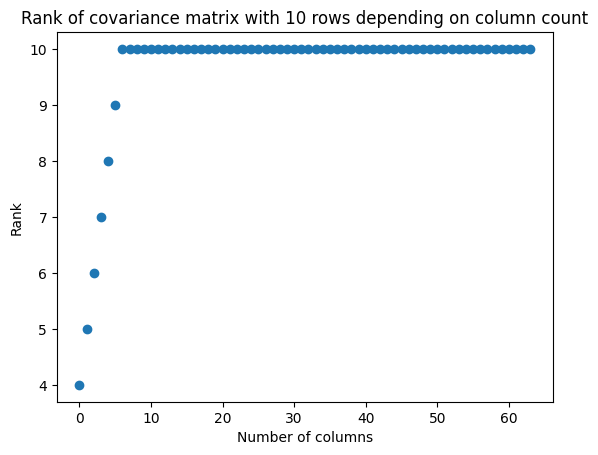

In [179]:
plt.scatter(range(len(ranks)), ranks)
plt.title("Rank of covariance matrix with 10 rows depending on column count")
plt.xlabel("Number of columns")
plt.ylabel("Rank")
plt.savefig("img/P1A_rank_vs_sample_size")
plt.show()

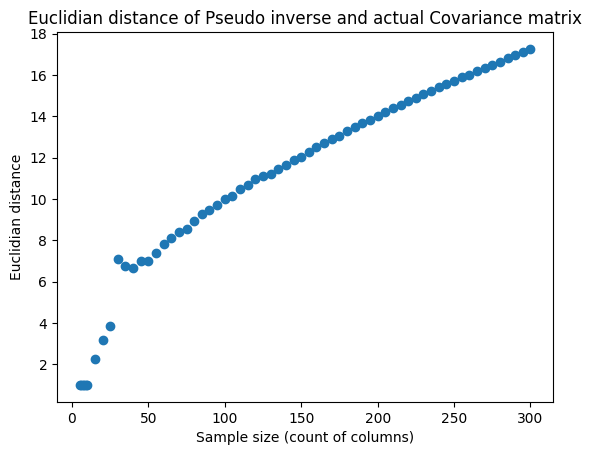

In [181]:
plt.scatter(m_list, eucl_dist)
plt.title("Euclidian distance of Pseudo inverse and actual Covariance matrix")
plt.xlabel("Sample size (count of columns)")
plt.ylabel("Euclidian distance")
plt.savefig("img/P1F_euclidian_dist_vs_m")
plt.show()